# Лабораторна робота №9
## Оцінка інформативності ознак за допомогою градієнтного бустингу

Мета роботи — за характеристиками рейсу спрогнозувати затримку вильоту більше ніж на 15 хвилин та визначити, які ознаки найбільше впливають на прогноз. Дані читаються локально з папки `lab9/data`.

In [1]:
# Якщо бібліотека ще не встановлена: python3 -m pip install xgboost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from xgboost import XGBClassifier

In [2]:
data_dir = Path('data')
if not (data_dir / 'flight_delays_train.csv').exists():
    data_dir = Path('lab9/data')
train = pd.read_csv(data_dir / 'flight_delays_train.csv')
test = pd.read_csv(data_dir / 'flight_delays_test.csv')
print('Розмір train:', train.shape)
print('Розмір test:', test.shape)
display(train.head())

Розмір train: (100000, 9)
Розмір test: (100000, 8)


,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
0,c-8,c-21,c-7,1934,AA,ATL,DFW,732,N
1,c-4,c-20,c-3,1548,US,PIT,MCO,834,N
2,c-9,c-2,c-5,1422,XE,RDU,CLE,416,N
3,c-11,c-25,c-6,1015,OO,DEN,MEM,872,N
4,c-10,c-7,c-6,1828,WN,MDW,OMA,423,Y


## Завдання 1. Підготовка вибірки
`Distance` і `DepTime` залишаємо без змін. Для `Origin` та `Dest` створюємо ознаку маршруту. Категоріальні ознаки кодуємо методом `LabelBinarizer` (one-hot encoding).

In [3]:
categorical_columns = ['Month', 'DayofMonth', 'DayOfWeek', 'UniqueCarrier', 'route']
numeric_columns = ['Distance', 'DepTime']

def prepare_features(frame, encoders):
    result = frame.copy()
    result['route'] = result['Origin'] + '_' + result['Dest']
    parts = [result[numeric_columns].reset_index(drop=True)]
    for column in categorical_columns:
        encoded = encoders[column].transform(result[column].astype(str))
        if encoded.ndim == 1:
            encoded = encoded.reshape(-1, 1)
        names = [f'{column}_{value}' for value in encoders[column].classes_]
        parts.append(pd.DataFrame(encoded, columns=names))
    return pd.concat(parts, axis=1)

train_for_encoding = train.copy()
test_for_encoding = test.copy()
train_for_encoding['route'] = train_for_encoding['Origin'] + '_' + train_for_encoding['Dest']
test_for_encoding['route'] = test_for_encoding['Origin'] + '_' + test_for_encoding['Dest']
encoders = {}
for column in categorical_columns:
    encoder = LabelBinarizer()
    encoder.fit(train_for_encoding[column].astype(str))
    encoders[column] = encoder

X = prepare_features(train, encoders)
X_test = prepare_features(test, encoders)
y = train['dep_delayed_15min'].map({'N': 0, 'Y': 1})
print('Кількість підготовлених ознак:', X.shape[1])
print('Розмірність X:', X.shape, '| X_test:', X_test.shape)
print('Частка затримок:', round(y.mean(), 4))

Кількість підготовлених ознак: 4503
Розмірність X: (100000, 4503) | X_test: (100000, 4503)
Частка затримок: 0.1904


## Завдання 2. XGBoost, підбір параметрів та інформативність ознак

In [4]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=17, stratify=y)
model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', tree_method='hist', n_estimators=150, random_state=17, n_jobs=-1)
param_grid = {'max_depth': [3, 5], 'learning_rate': [0.05, 0.1], 'subsample': [0.8]}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=17)
grid = GridSearchCV(model, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
print('Найкращі параметри:', grid.best_params_)
print('Найкращий середній ROC-AUC:', round(grid.best_score_, 4))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Найкращі параметри: {'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.8}
Найкращий середній ROC-AUC: 0.7191


In [5]:
best_model = grid.best_estimator_
valid_probabilities = best_model.predict_proba(X_valid)[:, 1]
valid_predictions = (valid_probabilities >= 0.5).astype(int)
print('ROC-AUC на validation:', round(roc_auc_score(y_valid, valid_probabilities), 4))
print('Accuracy на validation:', round(accuracy_score(y_valid, valid_predictions), 4))
print(classification_report(y_valid, valid_predictions, target_names=['Без затримки', 'Із затримкою']))

ROC-AUC на validation: 0.7374
Accuracy на validation: 0.8178
              precision    recall  f1-score   support

Без затримки       0.82      0.99      0.90     20239
Із затримкою       0.71      0.07      0.13      4761

    accuracy                           0.82     25000
   macro avg       0.77      0.53      0.51     25000
weighted avg       0.80      0.82      0.75     25000



Топ-20 найінформативніших ознак:


,Ознака,Важливість
1,DepTime,0.019047
11,Month_c-7,0.007726
62,UniqueCarrier_HA,0.007321
59,UniqueCarrier_EV,0.007061
61,UniqueCarrier_FL,0.006972
36,DayofMonth_c-3,0.006624
10,Month_c-6,0.006345
71,UniqueCarrier_WN,0.006318
63,UniqueCarrier_HP,0.006156
28,DayofMonth_c-22,0.006055


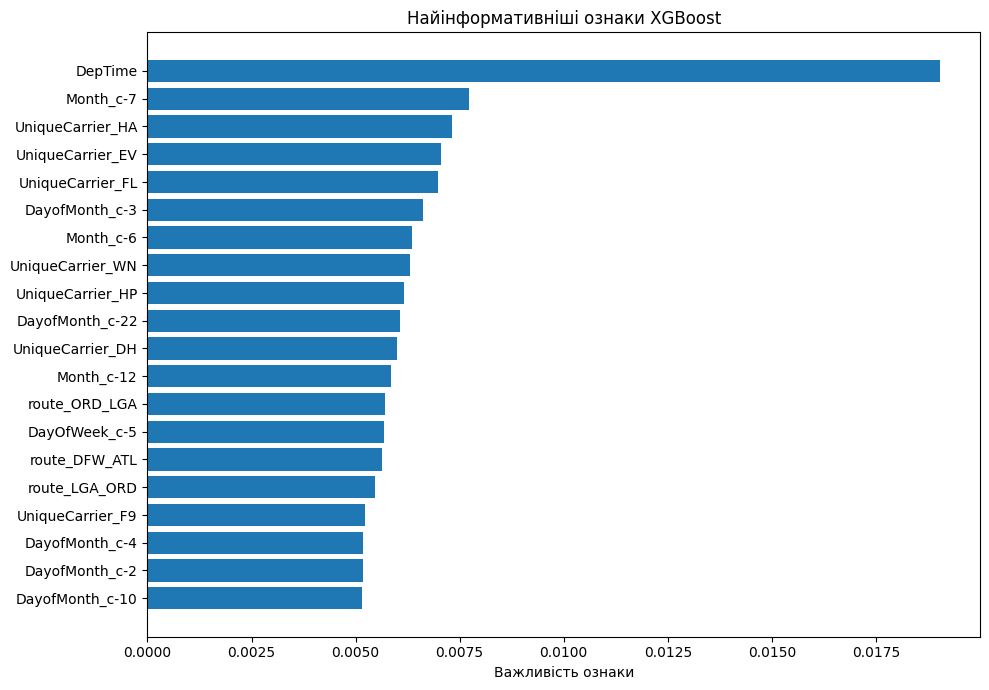

In [6]:
importance = pd.DataFrame({'Ознака': X.columns, 'Важливість': best_model.feature_importances_}).sort_values('Важливість', ascending=False)
print('Топ-20 найінформативніших ознак:')
display(importance.head(20))
top = importance.head(20).sort_values('Важливість')
plt.figure(figsize=(10, 7))
plt.barh(top['Ознака'], top['Важливість'])
plt.xlabel('Важливість ознаки')
plt.title('Найінформативніші ознаки XGBoost')
plt.tight_layout()
plt.show()

In [8]:
best_model.fit(X, y)
test_probabilities = best_model.predict_proba(X_test)[:, 1]
submission = pd.DataFrame({'dep_delayed_15min': test_probabilities})
results_dir = data_dir.parent / 'results'
results_dir.mkdir(exist_ok=True)
submission_path = results_dir / 'flight_delays_predictions.csv'
submission.to_csv(submission_path, index=False)
print('Файл із прогнозами створено:', submission_path)

# Виведемо рейси з найбільшою ймовірністю затримки.
delayed_flights = test.copy()
delayed_flights.insert(0, 'Номер запису', delayed_flights.index + 1)
delayed_flights['Маршрут'] = delayed_flights['Origin'] + ' → ' + delayed_flights['Dest']
delayed_flights['Ймовірність затримки'] = test_probabilities
delayed_flights['Прогноз'] = np.where(test_probabilities >= 0.5, 'Затримка', 'Без затримки')
delayed_flights = delayed_flights.sort_values('Ймовірність затримки', ascending=False)
columns_to_show = ['Номер запису', 'Маршрут', 'UniqueCarrier', 'DepTime', 'Distance', 'Ймовірність затримки', 'Прогноз']
print('10 рейсів із найбільшою ймовірністю затримки:')
display(delayed_flights[columns_to_show].head(10).style.format({'Ймовірність затримки': '{:.2%}'}))
detailed_path = results_dir / 'flight_delays_predictions_detailed.csv'
delayed_flights[columns_to_show].to_csv(detailed_path, index=False)
print('Детальні результати збережено:', detailed_path)

Файл із прогнозами створено: results/flight_delays_predictions.csv
10 рейсів із найбільшою ймовірністю затримки:


,Номер запису,Маршрут,UniqueCarrier,DepTime,Distance,Ймовірність затримки,Прогноз
22271,22272,JFK → CLT,B6,50,541,95.37%,Затримка
18602,18603,ORD → CMH,MQ,30,296,93.57%,Затримка
5557,5558,ORD → RIC,MQ,37,642,93.06%,Затримка
29747,29748,IAH → ORD,XE,22,925,92.91%,Затримка
18655,18656,JFK → ROC,B6,29,264,92.54%,Затримка
42703,42704,CVG → OMA,OH,48,614,92.43%,Затримка
4544,4545,ORD → IAH,UA,44,925,92.20%,Затримка
45939,45940,DEN → BIL,UA,154,455,92.17%,Затримка
17225,17226,ATL → OMA,EV,20,821,92.10%,Затримка
21777,21778,SFO → SAN,UA,26,447,92.10%,Затримка


Детальні результати збережено: results/flight_delays_predictions_detailed.csv
